# Excel Interface Demo

This notebook shows the final workbook-facing interface for the simulation framework.

In [3]:
from pathlib import Path
import sys

for folder in [Path.cwd(), *Path.cwd().parents]:
    src = folder / "src"
    if (src / "spm").exists():
        sys.path.insert(0, str(src))
        break
else:
    raise ModuleNotFoundError("Could not find the local src/spm package. Launch Jupyter inside the SPM repo or install the package with pip install -e .")

from spm.interfaces import excel_project_summary, load_project_from_excel

workbook = Path("cleaned_project_risk_dataset_UPDATED.xlsx")
if not workbook.exists():
    workbook = Path("Time and Cost experiment/Experiment/cleaned_project_risk_dataset_UPDATED.xlsx")

imported = load_project_from_excel(workbook, sample_count=10_000_000, rng_seed=2026)
project = imported.simulator_project

print(excel_project_summary(imported))

Project: cleaned_project_risk_dataset_UPDATED
Activities: 32
Risks: 15

id | predecessors | schedule risks | cost risks | E[D_i]
----------------------------------------------------------------
A1 | empty | - | - | 15.0
A2 | A1 | R2 | R10 | 30.0
A3 | A1 | - | - | 30.0
A7 | A1 | - | - | 70.0
A16 | A1 | - | - | 190.0
A5 | A2 | - | - | 70.0
A6 | A2 | R1 | - | 90.0
A17 | A2 | - | - | 55.0
A4 | A2, A3 | - | - | 55.0
A19 | A3 | - | - | 55.0
A11 | A7 | - | - | 80.0
A12 | A7 | R4 | - | 110.0
A13 | A7 | R3 | R12 | 80.0
A8 | A5 | - | R11 | 25.0
A9 | A5 | - | - | 85.0
A10 | A6 | - | - | 85.0
A18 | A17 | - | - | 60.0
A20 | A3, A4 | R5 | - | 95.0
A14 | A11, A13 | - | - | 30.0
A25 | A8 | - | - | 45.0
A21 | A18 | - | - | 25.0
A23 | A18 | R9 | - | 40.0
A29 | A12, A20 | - | - | 15.0
A15 | A14 | - | - | 15.0
A22 | A21 | - | - | 20.0
A24 | A21 | - | - | 40.0
A26 | A21, A25 | R6 | R13 | 85.0
A30 | A15, A16, A29 | R7 | R14 | 60.0
A27 | A9, A22, A23 | - | - | 80.0
A28 | A10, A24 | R8 | - | 60.0
A31 | A26, A

In [4]:
time_result = project.simulate_project_time_with_critical_activities()

completion = time_result["completion_times"]
critical_activity_probability = time_result["critical_activities"].mean(axis=1)

print(f"Mean project duration: {completion.mean():.2f} days")
print(f"P90 project duration: {__import__('numpy').quantile(completion, 0.90):.2f} days")

for node, probability in zip(time_result["topological_order"], critical_activity_probability):
    if probability > 0:
        print(f"A{node}: critical in {probability:.1%} of samples")

Mean project duration: 334.15 days
P90 project duration: 369.00 days
A1: critical in 100.0% of samples
A2: critical in 73.5% of samples
A3: critical in 10.1% of samples
A7: critical in 20.8% of samples
A16: critical in 0.2% of samples
A5: critical in 12.6% of samples
A6: critical in 5.6% of samples
A17: critical in 38.0% of samples
A4: critical in 30.1% of samples
A11: critical in 3.5% of samples
A12: critical in 9.2% of samples
A13: critical in 9.3% of samples
A8: critical in 11.9% of samples
A9: critical in 0.9% of samples
A10: critical in 5.6% of samples
A18: critical in 38.0% of samples
A20: critical in 30.1% of samples
A14: critical in 12.2% of samples
A25: critical in 11.9% of samples
A21: critical in 35.8% of samples
A23: critical in 2.3% of samples
A29: critical in 39.0% of samples
A15: critical in 12.2% of samples
A22: critical in 6.4% of samples
A24: critical in 24.0% of samples
A26: critical in 18.7% of samples
A30: critical in 50.3% of samples
A27: critical in 9.4% of sampl

In [5]:
project.simulate_all_costs()

expected_project_cost = project.expected_project_cost()
sample_project_costs = sum(
    work_package.get_cost_samples()
    for work_package in project.work_packages.values()
)
sample_project_cost_mean = sample_project_costs.mean()

print(f"Expected project cost: {expected_project_cost:.2f} x1000 monetary units")
print(f"Sample mean project cost: {sample_project_cost_mean:.2f} x1000 monetary units")
print(f"Sample mean - expected: {sample_project_cost_mean - expected_project_cost:.2f} x1000 monetary units")

Expected project cost: 10545.71 x1000 monetary units
Sample mean project cost: 10545.88 x1000 monetary units
Sample mean - expected: 0.18 x1000 monetary units


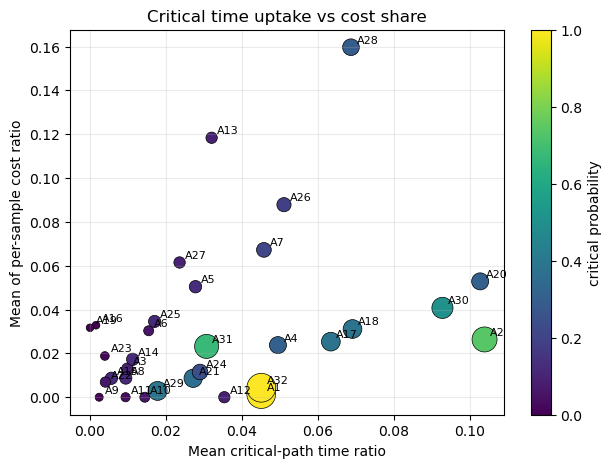

In [6]:
import matplotlib.pyplot as plt
import numpy as np

order = time_result["topological_order"]
completion = time_result["completion_times"].astype(float)
critical = time_result["critical_activities"]

duration_matrix = np.vstack([
    project.work_packages[node].duration_samples.astype(float)
    for node in order
])
cost_matrix = np.vstack([
    project.work_packages[node].get_cost_samples()
    for node in order
])
total_cost = cost_matrix.sum(axis=0)

project_time_ratio_vectors = np.divide(
    duration_matrix,
    completion[np.newaxis, :],
    out=np.zeros_like(duration_matrix, dtype=float),
    where=completion[np.newaxis, :] > 0,
)
critical_path_time_ratio_vectors = np.where(critical, project_time_ratio_vectors, 0.0)
# Per sample: activity cost divided by total project cost for that same realization.
cost_ratio_vectors = np.divide(
    cost_matrix,
    total_cost[np.newaxis, :],
    out=np.zeros_like(cost_matrix, dtype=float),
    where=total_cost[np.newaxis, :] > 0,
)

mean_critical_path_time_ratio = critical_path_time_ratio_vectors.mean(axis=1)
mean_cost_ratio = cost_ratio_vectors.mean(axis=1)
critical_probability = critical.mean(axis=1)
activity_labels = [f"A{node}" for node in order]

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    mean_critical_path_time_ratio,
    mean_cost_ratio,
    s=30 + 400 * np.asarray(critical_probability),
    c=critical_probability,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
)
for label, x_value, y_value in zip(activity_labels, mean_critical_path_time_ratio, mean_cost_ratio):
    ax.annotate(label, (x_value, y_value), xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.set_xlabel("Mean critical-path time ratio")
ax.set_ylabel("Mean of per-sample cost ratio")
ax.set_title("Critical time uptake vs cost share")
fig.colorbar(scatter, ax=ax, label="critical probability")
ax.grid(True, alpha=0.25)
plt.show()

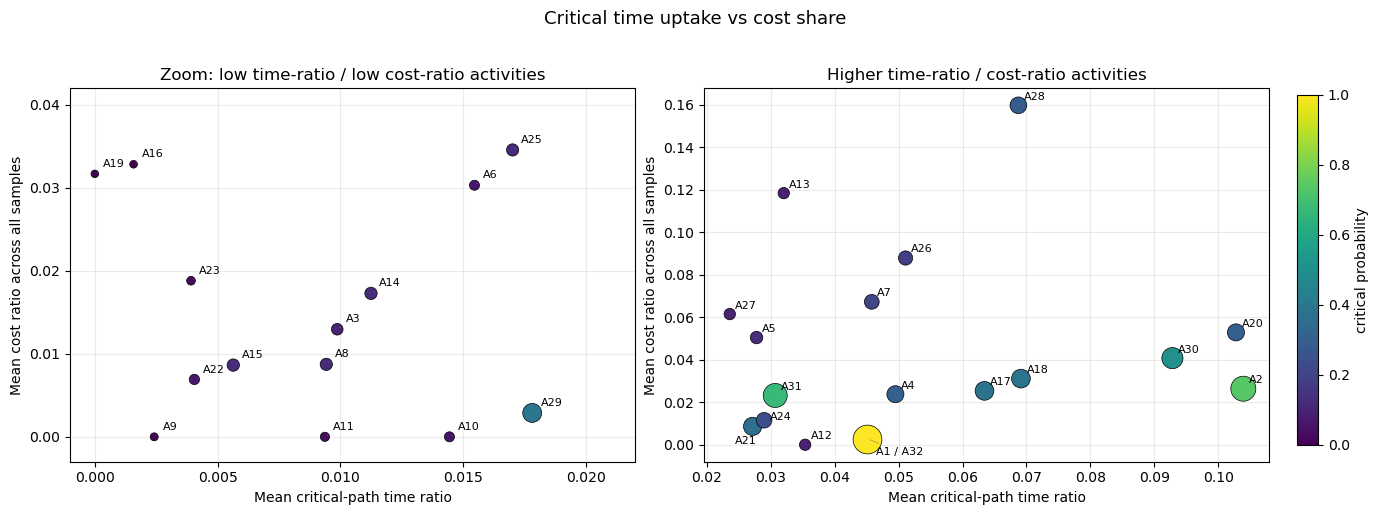

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1]})

cp = np.asarray(critical_probability)
xv = np.asarray(mean_critical_path_time_ratio)
yv = np.asarray(mean_cost_ratio)
labels = np.asarray(activity_labels)

crowded = (xv <= 0.02) & (yv <= 0.04)
overlap_pair = np.isin(labels, ["A1", "A32"])

vmin, vmax = cp.min(), cp.max()
scatter_kw = dict(cmap="viridis", edgecolor="black", linewidth=0.5, zorder=3, vmin=vmin, vmax=vmax)

# ---- Left panel ----
ax = axes[0]
idx = np.where(crowded)[0]
ax.scatter(xv[idx], yv[idx], s=30 + 400 * cp[idx], c=cp[idx], **scatter_kw)
for i in idx:
    ax.annotate(
        labels[i], (xv[i], yv[i]),
        xytext=(6, 5), textcoords="offset points", fontsize=8,
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
    )
ax.set_xlim(-0.001, 0.022)
ax.set_ylim(-0.003, 0.042)
ax.set_xlabel("Mean critical-path time ratio")
ax.set_ylabel("Mean cost ratio across all samples")
ax.set_title("Zoom: low time-ratio / low cost-ratio activities")
ax.grid(True, alpha=0.25)

# ---- Right panel ----
ax = axes[1]
idx = np.where(~crowded & ~overlap_pair)[0]
sc = ax.scatter(xv[idx], yv[idx], s=30 + 400 * cp[idx], c=cp[idx], **scatter_kw)
for i in idx:
    # inside the right-panel annotation loop, replace the generic annotate with:
        if labels[i] == "A21":
            dx, dy = -13, -13
        elif labels[i] == "A24":
            dx, dy = 4, 0
        else:
            dx, dy = 4, 4
        ax.annotate(
            labels[i], (xv[i], yv[i]),
            xytext=(dx, dy), textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
        )
   

pair_idx = np.where(overlap_pair)[0]
mx, my, mcp = xv[pair_idx].mean(), yv[pair_idx].mean(), cp[pair_idx].mean()
ax.scatter([mx], [my], s=30 + 400 * mcp, c=[mcp], **scatter_kw)
ax.annotate(
    "A1 / A32", (mx, my),
    xytext=(6, -12), textcoords="offset points", fontsize=8,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.4),
)

ax.set_xlabel("Mean critical-path time ratio")
ax.set_ylabel("Mean cost ratio across all samples")
ax.set_title("Higher time-ratio / cost-ratio activities")
ax.grid(True, alpha=0.25)

fig.suptitle("Critical time uptake vs cost share", fontsize=13, y=1.02)
plt.tight_layout()

# Colorbar pinned to the right edge, outside both panels
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label="critical probability")

plt.subplots_adjust(right=0.91)
plt.show()

In [ ]:
fig.savefig("critical_time_vs_cost.png", dpi=300, bbox_inches="tight")